# Importing Libraries

In [3]:
# import modules

# pandas - data science library that allows us to use data frames (data tables, datasets, etc.)
# numpy - (numerical python) is a math library and a basis for a lot of mathematical functions in Python
# os - has a number of functions for working with the operating system, including referencing directories and telling Python where to find files

import pandas as pd
import numpy as np
import os
from google.colab import drive
import requests
import io
from datetime import datetime
import time
import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import joblib

In [ ]:
# set the working directory explicitly so its easy to find where the files are located and saved in the future
drive.mount('/content/drive')

path = '/content/drive/My Drive/Full Corn Yield Prediction'

try:
    os.chdir(path)
    print("Successfully set working directory!")
    print(f"Current Directory: {os.getcwd()}")
    # List a few files to verify (v6, v12, r1, r3 data should be here)
    print(f"Files found: {os.listdir()[:5]}") 
except FileNotFoundError:
    print(f"Error: The path '{path}' was not found.")
    print("Check if the folder name in your Google Drive matches exactly.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully set working directory!
Current Directory: /content/drive/My Drive/Corn Yield Prediction - Data and Figures for Google Drive Mounting
Files found: ['anom_model_results.csv', 'tuning_dir_anom', 'tuning_dir_raw', 'models_anom', 'models_raw']


In [5]:
print(os.getcwd()) # print the current working directory to make sure it is what we expect
print(os.listdir()) # prints all files in the current working directory

/content
['.config', 'drive', 'sample_data']


# Primary Data - Corn

In [4]:
# Corn yield data downloaded from USDA NASS QuickStats > Field Crops > Corn > Yield > Corn, Grain - Yield, Measured in BU/Acrea > Total > County > 2000-2024
cornYieldData = pd.read_csv(r'Raw Data/Corn Yield in Bu Per Acre By County - 1998-2024.csv')

# Corn acres planted data downloaded from USDA NASS QuickStats > Field Crops > Corn > Area Planted > Corn - Acres Planted > Total > County > 1998-2024
cornAcresPlantedData = pd.read_csv(r'Raw Data/Corn Acres Planted By County - 1998-2024.csv')

 # Corn acres harvested data downloaded from USDA NASS QuickStats > Field Crops > Corn > Area Harvested > Corn, Grain - Acres Harvested > Total > County > 1998-2024
cornAcresHarvestedData = pd.read_csv(r'Raw Data/Corn Acres Harvested - 1998-2024.csv')

## Explore data

In [5]:
cornYieldData.dtypes

,0
Program,object
Year,int64
Period,object
Week Ending,float64
Geo Level,object
State,object
State ANSI,int64
Ag District,object
Ag District Code,int64
County,object


In [ ]:
cornYieldData.describe(include=['O', np.number])

In [ ]:
cornYieldData.shape

In [ ]:
cornAcresPlantedData.dtypes

In [ ]:
cornAcresPlantedData.describe(include=['O', np.number])

In [ ]:
cornAcresPlantedData.shape

In [ ]:
print(cornAcresHarvestedData.dtypes)

In [ ]:
print(cornAcresHarvestedData.describe(include=['O', np.number]))

## Data Cleaning

In [ ]:
cornYieldData.drop(['Program', 'Period', 'Week Ending', 'Geo Level', 'Ag District', 'Ag District Code', 'Zip Code', 'Region', 'watershed_code', 'Watershed', 'Commodity', 'Data Item', 'Domain', 'Domain Category', 'CV (%)'], axis=1, inplace=True)
cornYieldData.rename(columns={'Value': 'corn_yield'}, inplace=True)
cornYieldData.dropna(inplace=True)

if cornYieldData['corn_yield'].dtype == 'object':
    cornYieldData['corn_yield'] = cornYieldData['corn_yield'].str.replace(',', '').astype(float)

In [ ]:
cornAcresPlantedData.drop(['Program', 'Period', 'Week Ending', 'Geo Level', 'Ag District', 'Ag District Code', 'Zip Code', 'Region', 'watershed_code', 'Watershed', 'Commodity', 'Data Item', 'Domain', 'Domain Category', 'CV (%)'], axis=1, inplace=True)
cornAcresPlantedData.rename(columns={'Value': 'acres_planted_curr'}, inplace=True)
cornAcresPlantedData.dropna(inplace=True)

if cornAcresPlantedData['acres_planted_curr'].dtype == 'object':
    cornAcresPlantedData['acres_planted_curr'] = cornAcresPlantedData['acres_planted_curr'].str.replace(',', '').astype(float)

In [ ]:
cornAcresHarvestedData.drop(['Program', 'Period', 'Week Ending', 'Geo Level', 'Ag District', 'Ag District Code', 'Zip Code', 'Region', 'watershed_code', 'Watershed', 'Commodity', 'Data Item', 'Domain', 'Domain Category', 'CV (%)'], axis=1, inplace=True)
cornAcresHarvestedData.rename(columns={'Value': 'acres_harvested_curr'}, inplace=True)
cornAcresHarvestedData.dropna(inplace=True)

if cornAcresHarvestedData['acres_harvested_curr'].dtype == 'object':
    cornAcresHarvestedData['acres_harvested_curr'] = cornAcresHarvestedData['acres_harvested_curr'].str.replace(',', '').astype(float)

## Combining Dataframes

In [ ]:
# Standardize columns to merge by
for df in [cornYieldData, cornAcresPlantedData, cornAcresHarvestedData]:
    df['Year'] = df['Year'].astype(int)
    df['State'] = df['State'].str.strip().str.upper()
    df['County'] = df['County'].str.strip().str.upper()

In [ ]:
key_cols = ['Year', 'State', 'County']

# check that there are no duplicates of county and the same year. this should equal 0 !!
print(cornYieldData.duplicated(subset=key_cols).sum())
print(cornAcresPlantedData.duplicated(subset=key_cols).sum())
print(cornAcresHarvestedData.duplicated(subset=key_cols).sum())

cornData = cornYieldData.merge(
    cornAcresPlantedData[key_cols + ['acres_planted_curr']],
    on=key_cols,
    how='left'
)

cornData = cornData.merge(
    cornAcresHarvestedData[key_cols + ['acres_harvested_curr']],
    on=key_cols,
    how='left'
)

# Make sure no rows were added (this would be a sign that something went wrong)
print(cornYieldData.shape[0] == cornData.shape[0])

In [ ]:
cornData

## Finalize Columns

In [ ]:
cornData.rename(columns={'Year':'year', 'State':'state', 'State ANSI':'state_ansi', 'County':'county','County ANSI':'county_ansi'}, inplace=True)

In [ ]:
print(f'Shape: {cornData.shape}')
cornData.dtypes

### Create historical columns

In [ ]:
# PREP FOR CREATING ADDITIONAL COLUMNS

# get all county-state pairs
locations = cornData[['state_ansi', 'county_ansi', 'state', 'county']].drop_duplicates()

# make sure all county-state pairs have data (or an nan value) for all the expected years
all_years = pd.DataFrame({'year': range(cornData['year'].min(), cornData['year'].max() + 1)})
skeleton = locations.assign(key=1).merge(all_years.assign(key=1), on='key').drop('key', axis=1)
cornData_full = skeleton.merge(cornData, on=['year', 'state_ansi', 'county_ansi', 'state', 'county'], how='left')

# sort the data
cornData_full.sort_values(['state_ansi', 'county_ansi', 'year'], inplace=True)

cornData_full

In [ ]:
# FEATURE ENGINEERING

grouped = cornData_full.groupby(['state_ansi', 'county_ansi'])

# yield_prev_year: Corn yield the year before
cornData_full['yield_prev_year'] = grouped['corn_yield'].shift(1)

# yield_prev_five: The average corn yield over the past 5 years (not including current)
cornData_full['yield_prev_five'] = grouped['corn_yield'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=3).mean()
)

# helper: acres_planted_prev_five
cornData_full['acres_planted_prev_five'] = grouped['acres_planted_curr'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=3).mean()
)
# acres_planted_raw_anom
cornData_full['acres_planted_raw_anom'] = (
    cornData_full['acres_planted_curr'] - cornData_full['acres_planted_prev_five']
)
# acres_planted_pct_anom
cornData_full['acres_planted_pct_anom'] = (
    cornData_full['acres_planted_raw_anom'] / cornData_full['acres_planted_prev_five']
)

# helper: abandonment_curr = 1 - AcresHarvested/AcresPlanted
cornData_full['abandonment_curr'] = np.where(
    cornData_full['acres_planted_curr'] > 0,
    1 - (cornData_full['acres_harvested_curr'] / cornData_full['acres_planted_curr']),
    np.nan
)
# abandonment_rate_prev_five: 5-year average of the abandonment rate for that county
cornData_full['abandonment_rate_prev_five'] = grouped['abandonment_curr'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=3).mean()
)

# corn_yield_anom: secondary output (?) that stores the difference corn_yield (for current year) and yield_prev_five
cornData_full['corn_yield_anom'] = cornData_full['corn_yield'] - cornData_full['yield_prev_five']

In [ ]:
# CLEAN UP

# remove the years where no yield was reported. we had only added these so we could add historical columns correctly
cornData_final = cornData_full.dropna(subset=['corn_yield']).copy()
print(f"Valid county-years: {len(cornData_final)}. Should be same as original, which was {len(cornData)}")

# drop the helper columns
cornData_final.drop(columns=['abandonment_curr'], inplace=True)
cornData_final.drop(columns=['acres_planted_prev_five'], inplace=True)

# drop the columns with NAs (this will be the early years because they do not have enough historical data for yield_prev_year, yield_prev_five, etc.
cornData_final.dropna(inplace=True)

cornData_final

### Add FIPS and longitude and latitude (will be helpful for merging later)

In [ ]:
# Create fips only when both codes are present, else NaN

# Convert state/county codes to strings only if not null
state_str = cornData_final["state_ansi"].where(cornData_final["state_ansi"].notna()).astype(int).astype(str).str.zfill(2)
county_str = cornData_final["county_ansi"].where(cornData_final["county_ansi"].notna()).astype(int).astype(str).str.zfill(3)

# Combine them; if either is missing, result will be NaN
cornData_final["fips"] = state_str + county_str

cornData_final.head

In [ ]:
# upload and clean longitude and latitude data (data from: https://gist.github.com/russellsamora/12be4f9f574e92413ea3f92ce1bc58e6#file-us_county_latlng-csv)
countyLonLat = pd.read_csv(r'Raw Data\US County Longitude and Latitude.csv')
countyLonLat["fips_code"] = countyLonLat["fips_code"].astype(str).str.zfill(5)
countyLonLat.dtypes

In [ ]:
# add the longitude and latitude to the cornYieldDataCleaned dataframe based on the FIPS county code
cornData_final = cornData_final.merge(
    countyLonLat[["fips_code", "lng", "lat"]],
    how="left",
    left_on="fips",
    right_on="fips_code"
)

# Clean up extra columns and rename
cornData_final.drop(columns=["fips_code"], inplace=True)
cornData_final.rename(columns={'lng':'lon'}, inplace=True)

In [ ]:
# drop rows where fips/longitude/latitude is nan
cornData_final.dropna(inplace=True)

cornData_final.describe(include=['O', np.number])

### Final clean-up

In [ ]:
# reorder columns for convenience
cornData_final = cornData_final[[
    'year', 'state', 'state_ansi', 'county', 'county_ansi', 'fips', 'lon', 'lat',
    'yield_prev_year', 'yield_prev_five',
    'acres_planted_curr', 'acres_planted_raw_anom', 'acres_planted_pct_anom', 'abandonment_rate_prev_five',
    'corn_yield', 'corn_yield_anom',
    'acres_harvested_curr'
]]

# reset index which may have become messy
cornData_final.reset_index(drop=True, inplace=True)

In [ ]:
print(f'Shape: {cornData_final.shape}')
cornData_final.dtypes

In [ ]:
cornData_final
cornData_final.to_csv(r'Processed Data/cornData.csv', index=False)

In [5]:
corn_df = pd.read_csv(r'Processed Data\cornData.csv')

# Weather Data

In [ ]:
corn_df = pd.read_csv(r'Processed Data\cornData.csv')

# Get unique locations and the necessary time buffer for 10-year history
unique_locations = corn_df[['fips', 'lat', 'lon']].drop_duplicates()
min_year = corn_df['year'].min() - 10
max_year = corn_df['year'].max()

In [ ]:
# --- CONFIGURATION --- REVIEW THIS CODE BEFORE RUNNING (COPIED STRAIGHT FROM GEMINI RIGHT NOW)
CACHE_DIR = "weather_daily_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
BASE_PARAMS = "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,ALLSKY_SFC_SW_DWN,RH2M"

# --- 1. DATA ACQUISITION (NASA POWER) ---

def get_nasa_power_daily(lat, lon, start_year, end_year, fips, retries=5):
    """
    Fetches daily data and calculates raw daily metrics (GDD, SDD, VPD)
    to be stored in a county-level daily cache.
    """
    cache_path = os.path.join(CACHE_DIR, f"daily_{fips}_{start_year}_{end_year}.csv")
    if os.path.exists(cache_path):
        return pd.read_csv(cache_path, parse_dates=['date']).set_index('date')

    url = (
        f"https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"start={start_year}0101&end={end_year}1231"
        f"&latitude={lat}&longitude={lon}&community=ag"
        f"&parameters={BASE_PARAMS}&header=true&format=JSON"
    )

    for attempt in range(retries):
        try:
            response = requests.get(url, timeout=60)
            response.raise_for_status()
            data = response.json()
            
            params = data['properties']['parameter']
            df = pd.DataFrame({var: params[var] for var in params.keys()})
            df.index = pd.to_datetime(df.index, format='%Y%m%d')
            df.index.name = 'date'
            
            # Clean NASA fill values
            df = df.replace([-999, -99.0], np.nan)
            
            # --- DAILY FEATURE CALCULATION (Scientific Rigor) ---
            
            # 1. GDD (86/50 Method): (Tmax + Tmin)/2 - 50
            tmax_capped = df['T2M_MAX'].clip(upper=30, lower=10) # 86F = 30C, 50F = 10C
            tmin_capped = df['T2M_MIN'].clip(upper=30, lower=10)
            df['daily_gdd'] = ((tmax_capped + tmin_capped) / 2) - 10
            df['daily_gdd'] = df['daily_gdd'].clip(lower=0)

            # 2. SDD (Stress Degree Days): Tmax > 30C (86F)
            df['daily_sdd'] = (df['T2M_MAX'] - 30).clip(lower=0)

            # Heat Days: Tmax > 95F (35C)
            df['is_above_95'] = (df['T2M_MAX'] > 35).astype(int)

            # Diurnal Range: Tmax - Tmin
            df['diurnal_range'] = df['T2M_MAX'] - df['T2M_MIN']

            # 3. VPD (Vapor Pressure Deficit)
            # Saturation VP: es = 0.6108 * exp(17.27 * T / (T + 237.3))
            # Actual VP: ea = es * RH/100
            # VPD: es - ea
            df['es'] = 0.6108 * np.exp((17.27 * df['T2M']) / (df['T2M'] + 237.3))
            df['ea'] = df['es'] * (df['RH2M'] / 100)
            df['daily_vpd'] = df['es'] - df['ea']
            
            df.to_csv(cache_path)
            return df

        except Exception as e:
            print(f"Attempt {attempt+1} failed for {fips}: {e}")
            time.sleep(5)
    
    return None

# --- 2. AGGREGATION & PHENOLOGY WINDOWS ---

def process_county_weather(daily_df, years_needed):
    """
    Slices daily data into Growth Stages and calculates anomalies.
    """
    rows = []
    
    # Window format: (Start_Month, Start_Day, End_Month, End_Day, Is_Prev_Year)
    # Pre-season Non-Stage Windows
    pre_windows = {
        'full_season': (5, 1, 9, 30, False), # May 1 to Sept 30
        'oct_april':   (10, 1, 4, 30, True),  # Oct 1 (prev) to April 30
        'nov_mar':     (11, 1, 3, 31, True)   # Nov 1 (prev) to March 31
    }
    
    # define windows for stages of prediction
    stages = {
        'v6':  (5, 1, 5, 31, False),   # Oct 1 (prev) to May 31
        'v12': (6, 1, 6, 20, False),   # June 1 to June 20
        'r1':  (6, 21, 7, 10, False),  # June 21 to July 10
        'r3':  (7, 11, 7, 31, False)   # July 11 to July 31
    }

    
    for year in years_needed:
        data = {"year": year}

        # 1. Pre-season features
        for p_name, (sm, sd, em, ed, is_prev) in pre_windows.items():
            start = pd.Timestamp(year-1, sm, sd) if is_prev else pd.Timestamp(year, sm, sd)
            end = pd.Timestamp(year, em, ed)
            mask = daily_df.loc[start:end]
            data[f"{p_name}_precip"] = mask['PRECTOTCORR'].sum()
            data[f"{p_name}_gdd"] = mask['daily_gdd'].sum()
            if p_name == 'nov_mar':
                data["extreme_cold_nov_mar"] = (mask['T2M_MIN'] < -15).sum()

        # 2. Stage-dependent features
        for st, (sm, sd, em, ed, is_prev) in stages.items():
            start = pd.Timestamp(year-1, sm, sd) if is_prev else pd.Timestamp(year, sm, sd)
            end = pd.Timestamp(year, em, ed)
            mask = daily_df.loc[start:end]
            data[f"{st}_precip_curr"] = mask['PRECTOTCORR'].sum()
            data[f"{st}_gdd_curr"] = mask['daily_gdd'].sum()
            data[f"{st}_sdd_curr"] = mask['daily_sdd'].sum()
            data[f"{st}_days_above_95_curr"] = mask['is_above_95'].sum()
            data[f"{st}_vpd_mean"] = mask['daily_vpd'].mean()
            data[f"{st}_solar_curr"] = mask['ALLSKY_SFC_SW_DWN'].sum()
            data[f"{st}_night_temp_curr"] = mask['T2M_MIN'].mean()
            data[f"{st}_diurnal_temp_range_curr"] = mask['diurnal_range'].mean()
            
        rows.append(data)

    df_agg = pd.DataFrame(rows)
    
    # --- 3. CLIMATOLOGY (10-Year Rolling Anomalies) ---

    final = df_agg.copy()
    
    # 1. Non-Stage Pre-season History
    final['gdd_full_season_hist'] = df_agg['full_season_gdd'].shift(1).rolling(10, min_periods=5).mean()
    final['precip_full_season_hist'] = df_agg['full_season_precip'].shift(1).rolling(10, min_periods=5).mean()
    
    # 2. Oct-April Features
    oct_apr_hist = df_agg['oct_april_precip'].shift(1).rolling(10, min_periods=5).mean()
    final['precip_oct_april_curr'] = df_agg['oct_april_precip']
    final['precip_oct_april_anom'] = df_agg['oct_april_precip'] - oct_apr_hist

    # 3. Stage Anomalies
    stage_measures = ['precip_curr', 'gdd_curr', 'sdd_curr', 'days_above_95_curr', 'vpd_mean', 'solar_curr', 'night_temp_curr', 'diurnal_temp_range_curr']
    for st in stages.keys():
        for m in stage_measures:
            col = f"{st}_{m}"
            hist = df_agg[col].shift(1).rolling(10, min_periods=5).mean()
            final[f"{col.replace('_curr', '').replace('_mean', '')}_anom"] = df_agg[col] - hist

    # Drop intermediate helper columns used for calculation
    drop_cols = ['full_season_gdd', 'full_season_precip', 'oct_april_precip', 'oct_april_gdd', 'nov_mar_precip', 'nov_mar_gdd']
    return final.drop(columns=drop_cols)


In [ ]:
# Main execution loop

weather_master_list = []

for _, loc in tqdm.tqdm(unique_locations.iterrows(), total=len(unique_locations)):
    # 1. Get Daily Data (cached)
    daily_weather = get_nasa_power_daily(loc['lat'], loc['lon'], min_year, max_year, loc['fips'])
    
    if daily_weather is not None:
        # 2. Aggregate to Growth Stages & Calculate 10yr Anomalies
        # We only need rows for years actually present in corn_df for this county
        needed_years = corn_df[corn_df['fips'] == loc['fips']]['year'].unique()
        # But we pass the whole range to ensure rolling averages work
        all_years = range(min_year, max_year + 1)
        
        county_weather_df = process_county_weather(daily_weather, all_years)
        
        # 3. Tag with location keys and filter back to needed years
        county_weather_df['fips'] = str(loc['fips']).split('.')[0].zfill(5)
        weather_master_list.append(county_weather_df[county_weather_df['year'].isin(needed_years)])

# Combine all counties into one independent weatherData
weatherData = pd.concat(weather_master_list).reset_index(drop=True)
weatherData.dtypes

In [ ]:
weatherData.isna().sum()

In [ ]:
# reorder columns for ease

# 1. Define the lead columns (The "Identification" and "Baselines")
cols_order = [
    'year', 
    'fips', 
    'gdd_full_season_hist', 
    'precip_full_season_hist', 
    'precip_oct_april_curr', 
    'precip_oct_april_anom', 
    'extreme_cold_nov_mar'
]

# 2. Define the metrics that exist for every growth stage
# Note: we use the base names without _curr or _anom
metrics = [
    'precip', 'gdd', 'sdd', 'days_above_95', 
    'vpd', 'solar', 'night_temp', 'diurnal_temp_range'
]

# 3. Add stage specific metrics
for stage in ['v6', 'v12', 'r1', 'r3']:
    for m in metrics:
        # Standardize the suffix (handling 'mean' vs 'curr' logic)
        curr_col = f"{stage}_{m}_mean" if m == 'vpd' else f"{stage}_{m}_curr"
        anom_col = f"{stage}_{m}_anom"
        
        # Add them to our list if they exist in the dataframe
        if curr_col in weatherData.columns:
            cols_order.append(curr_col)
        if anom_col in weatherData.columns:
            cols_order.append(anom_col)

# 4. Reindex the dataframe
weatherData = weatherData[cols_order]

In [ ]:
# Save the independent weather features
weatherData.to_csv(r'Processed Data\weatherData.csv', index=False)

In [6]:
weather_df = pd.read_csv(r'Processed Data\weatherData.csv')

# Soil Data

In [27]:
corn_df = pd.read_csv(r'Processed Data\cornData.csv')

# Unique locations
unique_counties = corn_df[['state_ansi', 'county_ansi', 'fips']].drop_duplicates().copy()

STATE_ABBR = {
    1:"AL", 2:"AK", 4:"AZ", 5:"AR", 6:"CA", 8:"CO", 9:"CT", 10:"DE", 11:"DC",
    12:"FL", 13:"GA", 15:"HI", 16:"ID", 17:"IL", 18:"IN", 19:"IA", 20:"KS",
    21:"KY", 22:"LA", 23:"ME", 24:"MD", 25:"MA", 26:"MI", 27:"MN", 28:"MS",
    29:"MO", 30:"MT", 31:"NE", 32:"NV", 33:"NH", 34:"NJ", 35:"NM", 36:"NY",
    37:"NC", 38:"ND", 39:"OH", 40:"OK", 41:"OR", 42:"PA", 44:"RI", 45:"SC",
    46:"SD", 47:"TN", 48:"TX", 49:"UT", 50:"VT", 51:"VA", 53:"WA", 54:"WV",
    55:"WI", 56:"WY"
}

unique_counties["areasymbol"] = (
    unique_counties["state_ansi"].where(unique_counties["state_ansi"].notna()).map(STATE_ABBR)
    + unique_counties["county_ansi"].where(unique_counties["county_ansi"].notna()).astype(int).astype(str).str.zfill(3)
)

In [38]:
CACHE_FILE = "soil_cache.csv"

# properties to fetch
SOIL_PROPS = ["sandtotal_r", "silttotal_r", "claytotal_r", "om_r", "ph1to1h2o_r", "awc_r", "cec7_r"]
SOIL_MAP = {
    "sandtotal_r": "sand_pct", "silttotal_r": "silt_pct", "claytotal_r": "clay_pct",
    "om_r": "organic_matter_pct", "ph1to1h2o_r": "pH_soil", "awc_r": "awc_soil", "cec7_r": "cec_soil"
}

MAX_DEPTH = 30
BATCH_SIZE = 25

# Load existing cache or create empty
if os.path.exists(CACHE_FILE):
    soil_cache_df = pd.read_csv(CACHE_FILE)
    cached_areas = soil_cache_df['areasymbol'].unique().tolist()
    print(f"Loaded cache: {len(cached_areas)} counties already processed.")
else:
    soil_cache_df = pd.DataFrame()
    cached_areas = []

Loaded cache: 1813 counties already processed.


In [39]:
def fetch_soil_batch(areasymbols, max_depth):
    area_sql = ",".join(f"'{a}'" for a in areasymbols)
    sql = f"""
    SELECT l.areasymbol, co.comppct_r, co.slope_r,
           ch.hzdept_r, ch.hzdepb_r, ch.sandtotal_r, ch.silttotal_r,
           ch.claytotal_r, ch.om_r, ch.ph1to1h2o_r, ch.awc_r, ch.cec7_r
    FROM legend l
    JOIN mapunit mu ON l.lkey = mu.lkey
    JOIN component co ON mu.mukey = co.mukey
    JOIN chorizon ch ON co.cokey = ch.cokey
    WHERE l.areasymbol IN ({area_sql}) AND co.majcompflag = 'Yes' AND ch.hzdept_r < {max_depth}
    """
    try:
        r = requests.post("https://sdmdataaccess.nrcs.usda.gov/Tabular/post.rest", 
                          json={"query": sql, "format": "JSON+COLUMNNAME"}, timeout=60)
        if r.status_code != 200: return pd.DataFrame()
        table = r.json().get("Table", [])
        if len(table) <= 1: return pd.DataFrame()
        
        df = pd.DataFrame(table[1:], columns=table[0])
        num_cols = ["comppct_r", "slope_r", "hzdept_r", "hzdepb_r"] + SOIL_PROPS
        df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

        rows = []
        for areasymbol, group in df.groupby("areasymbol"):
            rec = {"areasymbol": areasymbol, "slope": round(group["slope_r"].mean(), 2)}
            for prop in SOIL_PROPS:
                w_sum, w_total = 0.0, 0.0
                for _, row in group.iterrows():
                    thickness = max(min(row.hzdepb_r, max_depth) - row.hzdept_r, 0)
                    if thickness > 0 and pd.notnull(row[prop]):
                        weight = thickness * (row.comppct_r / 100)
                        w_sum += weight * row[prop]
                        w_total += weight
                rec[SOIL_MAP[prop]] = round(w_sum / w_total, 3) if w_total > 0 else None
            rows.append(rec)
        return pd.DataFrame(rows)
    except Exception:
        return pd.DataFrame()

In [40]:
all_areas = unique_counties["areasymbol"].dropna().unique().tolist()
# Filter out what we already have
areas_to_fetch = [a for a in all_areas if a not in cached_areas]

if not areas_to_fetch:
    print("All counties already in cache.")
else:
    batches = [areas_to_fetch[i:i+BATCH_SIZE] for i in range(0, len(areas_to_fetch), BATCH_SIZE)]
    
    for batch in tqdm.tqdm(batches, desc="Fetching Missing Soil Data"):
        dfb = fetch_soil_batch(batch, MAX_DEPTH)
        
        if not dfb.empty:
            # Append to cache file immediately
            file_exists = os.path.isfile(CACHE_FILE)
            dfb.to_csv(CACHE_FILE, mode='a', index=False, header=not file_exists)

Fetching Missing Soil Data: 100%|██████████| 10/10 [00:03<00:00,  2.71it/s]


In [41]:
# Reload full cache to ensure we have everything
soil_cache = pd.read_csv(CACHE_FILE)
soilData = unique_counties[['fips', 'areasymbol']].merge(soil_cache, on="areasymbol", how="inner")
soilData = soilData.drop(columns=['areasymbol']).drop_duplicates()

print(f'unique_counties shape: {unique_counties.shape}, soilData shape: {soilData.shape}')
soilData

unique_counties shape: (2062, 4), soilData shape: (1813, 9)


,fips,slope,sand_pct,silt_pct,clay_pct,organic_matter_pct,pH_soil,awc_soil,cec_soil
0,1001,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
2,1003,4.94,61.753,23.081,12.615,2.925,5.098,0.135,10.595
4,1005,8.17,65.569,16.885,17.546,1.101,5.093,0.109,12.107
6,1009,8.97,32.913,42.548,24.539,1.294,5.104,0.151,10.290
8,1013,7.22,51.464,23.583,22.478,0.967,5.311,0.127,11.851
...,...,...,...,...,...,...,...,...,...
2902,55137,4.51,70.392,17.782,11.826,9.448,6.091,0.156,16.004
2906,55139,4.67,40.512,39.166,20.242,6.827,6.667,0.191,17.938
2910,55141,3.07,55.514,31.733,9.469,11.661,5.338,0.195,22.501
2914,56031,10.68,58.864,24.643,15.661,1.329,7.729,0.133,10.140


In [42]:
soilData.isna().sum()

fips                  0
slope                 0
sand_pct              0
silt_pct              0
clay_pct              0
organic_matter_pct    0
pH_soil               0
awc_soil              0
cec_soil              0
dtype: int64

In [43]:
soilData.to_csv(r'Processed Data\soilData.csv', index=False)

In [7]:
soil_df = pd.read_csv(r'Processed Data\soilData.csv')

# Vegetation Data

In [52]:
!pip install earthengine-api
!pip install geemap

   ---------------------------------------- 0.0/476.3 kB ? eta -:--:--
   ----------------------- ---------------- 276.5/476.3 kB 8.6 MB/s eta 0:00:01
   ---------------------------------------  471.0/476.3 kB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 476.3/476.3 kB 5.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/14.9 MB ? eta -:--:--
   - -------------------------------------- 0.6/14.9 MB 20.5 MB/s eta 0:00:01
   --- ------------------------------------ 1.2/14.9 MB 15.8 MB/s eta 0:00:01
   ---- ----------------------------------- 1.8/14.9 MB 14.3 MB/s eta 0:00:01
   ------ --------------------------------- 2.5/14.9 MB 14.3 MB/s eta 0:00:01
   -------- ------------------------------- 3.0/14.9 MB 13.8 MB/s eta 0:00:01
   --------- ------------------------------ 3.6/14.9 MB 13.7 MB/s eta 0:00:01
   ----------- ---------------------------- 4.4/14.9 MB 13.9 MB/s eta 0:00:01
   ------------- -------------------------- 5.0/14.9 MB 13.9 MB/s eta 0:0

In [4]:
import ee

# 1. Initialize and authenticate
# Follow the link in the output to log in
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='corn-prediction') # Change this to your project name

In [5]:
corn_df = pd.read_csv(r'Processed Data\cornData.csv')

# Preload the county collection once to avoid re-initializing it 34,000 times
COUNTIES = ee.FeatureCollection("TIGER/2018/Counties")

STAGES = {
    'v6': (5, 31),
    'v12': (6, 20),
    'r1': (7, 10),
    'r3': (7, 31)
}

def get_county_vegetation_final(fips, year):
    # 1. FIX FIPS: Ensure it is a 5-digit string
    fips_str = str(int(fips)).zfill(5)
    
    # 2. FILTER COUNTY
    county_roi = COUNTIES.filter(ee.Filter.eq('GEOID', fips_str)).geometry()
    
    # 3. FIX MASK YEAR: Handle early years (CDL starts ~2008 nationally)
    # If year is before 2008, fallback to 2008 mask. If future, use 2023.
    if year > 2023:
        mask_year = 2023
    elif year < 2008:
        mask_year = 2008
    else:
        mask_year = year
        
    corn_mask = ee.Image(f"USDA/NASS/CDL/{mask_year}").select('cropland').eq(1)

    results = {'fips': fips, 'year': year}

    for stage, (month, day) in STAGES.items():
        # --- ROBUST DATE CONSTRUCTION ---
        # Instead of passing ints to ee.Date, we create a string "YYYY-MM-DD"
        # This bypasses the error you are seeing.
        date_str = f"{year}-{month:02d}-{day:02d}"
        
        end_date = ee.Date(date_str)
        start_date = end_date.advance(-16, 'day')
        
        # --- 1. CURRENT DATA ---
        curr_raw = ee.ImageCollection("MODIS/061/MOD13Q1") \
            .filterBounds(county_roi) \
            .filterDate(start_date, end_date) \
            .max() # Best pixel
        
        # Helper to add NDWI
        def add_indices(img):
            img = img.multiply(0.0001)
            evi = img.select('EVI')
            ndwi = img.expression(
                '(NIR - MIR) / (NIR + MIR)', {
                    'NIR': img.select('sur_refl_b02'),
                    'MIR': img.select('sur_refl_b07')
                }
            ).rename('NDWI')
            return evi.addBands(ndwi)
            
        curr_img = add_indices(curr_raw).updateMask(corn_mask)

        # --- 2. HISTORICAL BASELINE ---
        doy_start = start_date.getRelative('day', 'year')
        doy_end = end_date.getRelative('day', 'year')
        
        hist_col = ee.ImageCollection("MODIS/061/MOD13Q1") \
            .filterBounds(county_roi) \
            .filter(ee.Filter.calendarRange(year - 10, year - 1, 'year')) \
            .filter(ee.Filter.dayOfYear(doy_start, doy_end)) \
            .map(add_indices)
        
        hist_mean_img = hist_col.mean().updateMask(corn_mask)

        # --- 3. EXECUTE REQUEST ---
        try:
            # We use a larger scale if errors persist, but 250m is ideal
            curr_stats = curr_img.reduceRegion(
                reducer=ee.Reducer.mean(), geometry=county_roi, scale=250, maxPixels=1e9
            ).getInfo()
            
            hist_stats = hist_mean_img.reduceRegion(
                reducer=ee.Reducer.mean(), geometry=county_roi, scale=250, maxPixels=1e9
            ).getInfo()
            
            for metric in ['EVI', 'NDWI']:
                c = curr_stats.get(metric)
                h = hist_stats.get(metric)
                col = f"{stage}_{metric.lower()}"
                
                results[f"{col}_curr"] = c
                if c is not None and h is not None:
                    results[f"{col}_anom"] = c - h
                else:
                    results[f"{col}_anom"] = None

        except Exception as e:
            # If a specific stage fails, we fill None but don't crash the whole row
            for metric in ['evi', 'ndwi']:
                results[f"{stage}_{metric}_curr"] = None
                results[f"{stage}_{metric}_anom"] = None

    return results

In [9]:
# --- 3. EXECUTION LOOP ---

CHECKPOINT_FILE = 'Processed Data\\vegetationData.csv'

# Identify Tasks
tasks = corn_df[['fips', 'year']].drop_duplicates()

# Check for existing progress
if os.path.exists(CHECKPOINT_FILE):
    existing_df = pd.read_csv(CHECKPOINT_FILE)
    # Create key: fips_year
    finished_keys = set(existing_df['fips'].astype(str) + "_" + existing_df['year'].astype(str))
    print(f"Resuming... {len(finished_keys)} already done.")
else:
    finished_keys = set()

# Filter remaining
remaining_tasks = tasks[~(tasks['fips'].astype(str) + "_" + tasks['year'].astype(str)).isin(finished_keys)]
print(f"Processing {len(remaining_tasks)} rows...")

batch_results = []

# Using tqdm.notebook
for i, (_, row) in enumerate(tqdm.tqdm(remaining_tasks.iterrows(), total=len(remaining_tasks), desc="Fetching Data")):
    
    try:
        # Explicit type conversion to prevent errors
        fips_input = row['fips'] 
        year_input = int(row['year']) 
        
        data = get_county_vegetation_final(fips_input, year_input)
        batch_results.append(data)
        
    except Exception as e:
        print(f"Error on FIPS {row['fips']} Year {row['year']}: {e}")
        continue
    
    # Save every 20 rows
    if (i + 1) % 20 == 0:
        pd.DataFrame(batch_results).to_csv(CHECKPOINT_FILE, mode='a', index=False, header=not os.path.exists(CHECKPOINT_FILE))
        batch_results = []
    
    # time.sleep(0.05)

# Final Save
if batch_results:
    pd.DataFrame(batch_results).to_csv(CHECKPOINT_FILE, mode='a', index=False, header=not os.path.exists(CHECKPOINT_FILE))

print("Completed.")

Resuming... 34309 already done.
Processing 0 rows...


Fetching Data: 0it [00:00, ?it/s]

Completed.


# Final Data

## Initial

### Preview

In [8]:
# get individual processed datasets
corn_df = pd.read_csv(r'Processed Data/cornData.csv')
weather_df = pd.read_csv(r'Processed Data/weatherData.csv')
soil_df = pd.read_csv(r'Processed Data/soilData.csv')
vegetation_df = pd.read_csv(r'Processed Data/vegetationData.csv')

In [11]:
corn_df

,year,state,state_ansi,county,county_ansi,fips,lon,lat,yield_prev_year,yield_prev_five,acres_planted_curr,acres_planted_raw_anom,acres_planted_pct_anom,abandonment_rate_prev_five,corn_yield,corn_yield_anom,acres_harvested_curr
0,2001,ALABAMA,1,AUTAUGA,1.0,1001,-86.642900,32.535142,31.0,46.666667,1400.0,-966.666667,-0.408451,0.437785,71.0,24.333333,1200.0
1,2002,ALABAMA,1,AUTAUGA,1.0,1001,-86.642900,32.535142,71.0,52.750000,2900.0,775.000000,0.364706,0.364053,52.0,-0.750000,2000.0
2,2003,ALABAMA,1,AUTAUGA,1.0,1001,-86.642900,32.535142,52.0,52.600000,3500.0,1220.000000,0.535088,0.353311,120.0,67.400000,2400.0
3,2004,ALABAMA,1,AUTAUGA,1.0,1001,-86.642900,32.535142,120.0,70.000000,3400.0,980.000000,0.404959,0.280454,83.0,13.000000,1700.0
4,2005,ALABAMA,1,AUTAUGA,1.0,1001,-86.642900,32.535142,83.0,71.400000,2700.0,0.000000,0.000000,0.340454,103.0,31.600000,2300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34304,2005,WYOMING,56,PLATTE,31.0,56031,-104.966132,42.132391,116.0,127.200000,10500.0,-960.000000,-0.083770,0.747300,135.0,7.800000,5000.0
34305,2006,WYOMING,56,PLATTE,31.0,56031,-104.966132,42.132391,135.0,128.000000,10500.0,-860.000000,-0.075704,0.730244,109.0,-19.000000,1900.0
34306,2007,WYOMING,56,PLATTE,31.0,56031,-104.966132,42.132391,109.0,127.200000,11100.0,-40.000000,-0.003591,0.752674,145.0,17.800000,5600.0
34307,2003,WYOMING,56,WASHAKIE,43.0,56043,-107.682315,43.904378,153.0,135.666667,4500.0,133.333333,0.030534,0.434398,134.0,-1.666667,1800.0


In [12]:
weather_df

,year,fips,gdd_full_season_hist,precip_full_season_hist,precip_oct_april_curr,precip_oct_april_anom,extreme_cold_nov_mar,v6_precip_curr,v6_precip_anom,v6_gdd_curr,...,r3_days_above_95_curr,r3_days_above_95_anom,r3_vpd_mean,r3_vpd_anom,r3_solar_curr,r3_solar_anom,r3_night_temp_curr,r3_night_temp_anom,r3_diurnal_temp_range_curr,r3_diurnal_temp_range_anom
0,2001,1001,2202.467,530.365,970.88,140.023,0,92.98,5.032,352.420,...,3,-2.8,1.050387,0.084482,453.34,10.949,21.183333,-1.392667,12.270476,1.573667
1,2002,1001,2192.039,521.520,648.77,-217.557,0,75.75,1.056,377.815,...,6,-0.1,0.964555,-0.039284,444.81,1.412,22.782857,0.351857,10.855714,-0.153810
2,2003,1001,2209.140,517.316,924.61,71.240,0,194.54,116.918,395.570,...,0,-6.5,0.659755,-0.369055,435.65,-9.910,21.727619,-0.736714,9.640952,-1.534381
3,2004,1001,2206.967,552.159,549.61,-298.520,0,100.22,9.913,405.345,...,8,2.8,1.068952,0.087187,465.71,23.287,22.005714,-0.312190,12.225714,1.277857
4,2005,1001,2215.656,553.033,904.46,83.435,0,98.80,4.266,331.025,...,3,-3.0,0.740200,-0.291530,413.10,-34.191,23.203333,0.785095,9.347619,-1.926714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34254,2005,56031,1384.944,238.961,184.52,13.002,3,77.36,11.147,154.800,...,7,2.7,1.796132,0.044949,566.71,35.842,15.734762,0.059048,16.902857,1.108476
34255,2006,56031,1400.690,235.791,201.99,29.548,8,37.58,-19.837,198.570,...,10,5.4,2.238660,0.462589,553.36,18.618,17.453333,1.606857,16.921905,1.001810
34256,2007,56031,1409.392,234.601,224.85,49.200,7,71.60,18.716,181.535,...,5,-0.6,1.728444,-0.129705,509.66,-26.388,16.968095,0.813524,15.401905,-0.707952
34257,2003,56043,1189.322,202.012,207.74,-4.707,7,49.14,-5.514,145.240,...,4,2.9,1.999077,0.512516,566.02,11.699,16.653333,3.022571,16.317619,0.981762


In [13]:
soil_df

,fips,slope,sand_pct,silt_pct,clay_pct,organic_matter_pct,pH_soil,awc_soil,cec_soil
0,1001,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
1,1003,4.94,61.753,23.081,12.615,2.925,5.098,0.135,10.595
2,1005,8.17,65.569,16.885,17.546,1.101,5.093,0.109,12.107
3,1009,8.97,32.913,42.548,24.539,1.294,5.104,0.151,10.290
4,1013,7.22,51.464,23.583,22.478,0.967,5.311,0.127,11.851
...,...,...,...,...,...,...,...,...,...
1808,55137,4.51,70.392,17.782,11.826,9.448,6.091,0.156,16.004
1809,55139,4.67,40.512,39.166,20.242,6.827,6.667,0.191,17.938
1810,55141,3.07,55.514,31.733,9.469,11.661,5.338,0.195,22.501
1811,56031,10.68,58.864,24.643,15.661,1.329,7.729,0.133,10.140


In [14]:
vegetation_df

,fips,year,v6_evi_curr,v6_evi_anom,v6_ndwi_curr,v6_ndwi_anom,v12_evi_curr,v12_evi_anom,v12_ndwi_curr,v12_ndwi_anom,r1_evi_curr,r1_evi_anom,r1_ndwi_curr,r1_ndwi_anom,r3_evi_curr,r3_evi_anom,r3_ndwi_curr,r3_ndwi_anom
0,1001,2001,0.381932,0.010730,0.315088,0.016575,0.314775,-0.080391,0.456352,0.153687,0.479693,0.094452,0.482342,0.139916,0.434842,0.030347,0.474754,0.169702
1,1001,2002,0.387097,0.010530,0.404549,0.097749,0.387282,0.031356,0.351173,-0.028061,0.466615,0.034148,0.447329,0.034945,0.501034,0.081365,0.493593,0.103690
2,1001,2003,0.394618,0.014541,0.501640,0.162256,0.454487,0.088234,0.533886,0.164138,0.487625,0.043776,0.487436,0.063404,0.482932,0.036142,0.558162,0.133696
3,1001,2004,0.418297,0.034584,0.398526,0.018578,0.429300,0.040893,0.518225,0.107190,0.481139,0.026345,0.608897,0.169014,0.491565,0.035740,0.545659,0.087769
4,1001,2005,0.372892,-0.017738,0.325133,-0.058530,0.445986,0.049423,0.452813,0.020331,0.457686,-0.002377,0.513912,0.040226,0.574995,0.112021,0.642980,0.167536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34304,56031,2005,0.344265,-0.021139,0.201378,-0.031295,0.387504,0.038755,0.270899,0.060387,0.345696,-0.033016,0.245072,-0.024976,0.528912,0.071192,0.484049,0.120621
34305,56031,2006,0.305820,-0.056061,0.175540,-0.051917,0.265052,-0.090156,0.095177,-0.125400,0.329030,-0.044180,0.200634,-0.065252,0.498902,0.029317,0.370729,-0.012803
34306,56031,2007,0.323003,-0.030869,0.191638,-0.028402,0.279470,-0.062859,0.130784,-0.071878,0.340854,-0.026045,0.237789,-0.018774,0.511452,0.037679,0.412501,0.030798
34307,56043,2003,0.439349,0.085286,0.347746,0.096900,0.469255,0.061446,0.371181,0.039554,0.528790,0.082389,0.510936,0.058615,0.450539,0.030057,0.427187,0.041556


### Make sure fip-year pairs are unique for each df (prevents issues with merging)

In [15]:
# List of dynamic dataframes (year + fips)
dynamic_dfs = {
    "corn_df": corn_df,
    "weather_df": weather_df,
    "vegetation_df": vegetation_df
}

print("--- Uniqueness Check ---")

for name, df in dynamic_dfs.items():
    # Identify duplicates based on fips and year
    duplicate_mask = df.duplicated(subset=['fips', 'year'], keep=False)
    num_duplicates = duplicate_mask.sum()
    
    if num_duplicates > 0:
        print(f"⚠️ {name}: Found {num_duplicates} duplicate FIPS-Year rows.")
    else:
        print(f"✅ {name}: Every FIPS-Year pair is unique.")

# Special check for soil_df (fips only)
soil_duplicates = soil_df.duplicated(subset=['fips'], keep=False).sum()
if soil_duplicates > 0:
    print(f"⚠️ soil_df: Found {soil_duplicates} duplicate FIPS rows.")
else:
    print("✅ soil_df: Every FIPS is unique.")

--- Uniqueness Check ---
✅ corn_df: Every FIPS-Year pair is unique.
✅ weather_df: Every FIPS-Year pair is unique.
✅ vegetation_df: Every FIPS-Year pair is unique.
✅ soil_df: Every FIPS is unique.


### Merge dataframes into one

In [16]:
master_df = pd.merge(corn_df, weather_df, on=['fips', 'year'], how='left')
master_df = pd.merge(master_df, vegetation_df, on=['fips', 'year'], how='left')
# because soil_df lacks a 'year' column, pandas will automatically broadcast the static soil values to every year for a matching FIPS.
master_df = pd.merge(master_df, soil_df, on='fips', how='left')

print("--- Merge Results ---")
print(f"Final Shape: {master_df.shape}")
print(f"Columns added: {list(master_df.columns)}")

--- Merge Results ---
Final Shape: (34309, 110)
Columns added: ['year', 'state', 'state_ansi', 'county', 'county_ansi', 'fips', 'lon', 'lat', 'yield_prev_year', 'yield_prev_five', 'acres_planted_curr', 'acres_planted_raw_anom', 'acres_planted_pct_anom', 'abandonment_rate_prev_five', 'corn_yield', 'corn_yield_anom', 'acres_harvested_curr', 'gdd_full_season_hist', 'precip_full_season_hist', 'precip_oct_april_curr', 'precip_oct_april_anom', 'extreme_cold_nov_mar', 'v6_precip_curr', 'v6_precip_anom', 'v6_gdd_curr', 'v6_gdd_anom', 'v6_sdd_curr', 'v6_sdd_anom', 'v6_days_above_95_curr', 'v6_days_above_95_anom', 'v6_vpd_mean', 'v6_vpd_anom', 'v6_solar_curr', 'v6_solar_anom', 'v6_night_temp_curr', 'v6_night_temp_anom', 'v6_diurnal_temp_range_curr', 'v6_diurnal_temp_range_anom', 'v12_precip_curr', 'v12_precip_anom', 'v12_gdd_curr', 'v12_gdd_anom', 'v12_sdd_curr', 'v12_sdd_anom', 'v12_days_above_95_curr', 'v12_days_above_95_anom', 'v12_vpd_mean', 'v12_vpd_anom', 'v12_solar_curr', 'v12_solar_anom'

### Final Clean (delete NAs, change column data types)

In [17]:
# Check for missing data after merge
missing_counts = master_df.isnull().sum()
print(missing_counts)

year                     0
state                    0
state_ansi               0
county                   0
county_ansi              0
                      ... 
clay_pct              2909
organic_matter_pct    2909
pH_soil               2909
awc_soil              2909
cec_soil              2909
Length: 110, dtype: int64


In [18]:
# Check how many rows have at least one NaN
initial_rows = len(master_df)
rows_with_nas = master_df.isnull().any(axis=1).sum()
print(f"Total rows before cleaning: {initial_rows}, Rows containing missing values: {rows_with_nas}")

# Drop rows where ANY column has a NaN
master_df_clean = master_df.dropna().reset_index(drop=True)

final_rows = len(master_df_clean)
print(f"Final rows after dropping NaNs: {final_rows}, Percentage of data retained: {(final_rows/initial_rows)*100:.2f}%")

Total rows before cleaning: 34309, Rows containing missing values: 2960
Final rows after dropping NaNs: 31349, Percentage of data retained: 91.37%


In [19]:
master_df_clean.dtypes

,0
year,int64
state,object
state_ansi,int64
county,object
county_ansi,float64
...,...
clay_pct,float64
organic_matter_pct,float64
pH_soil,float64
awc_soil,float64


In [20]:
# Fix column data types (fips, county_ansi, and state_ansi should be strings)

master_df_clean['state_ansi'] = master_df_clean['state_ansi'].astype(str)
master_df_clean['county_ansi'] = master_df_clean['county_ansi'].astype(str).str.replace('.0', '', regex=False)
master_df_clean['fips'] = master_df_clean['fips'].astype(str)

# Fix leading zeros
master_df_clean['fips'] = master_df_clean['fips'].str.zfill(5)
master_df_clean['state_ansi'] = master_df_clean['state_ansi'].str.zfill(2)
master_df_clean['county_ansi'] = master_df_clean['county_ansi'].str.zfill(3)

In [21]:
master_df_clean.head(10)

,year,state,state_ansi,county,county_ansi,fips,lon,lat,yield_prev_year,yield_prev_five,...,r3_ndwi_curr,r3_ndwi_anom,slope,sand_pct,silt_pct,clay_pct,organic_matter_pct,pH_soil,awc_soil,cec_soil
0,2001,ALABAMA,01,AUTAUGA,001,01001,-86.642900,32.535142,31.0,46.666667,...,0.474754,0.169702,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
1,2002,ALABAMA,01,AUTAUGA,001,01001,-86.642900,32.535142,71.0,52.750000,...,0.493593,0.103690,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
2,2003,ALABAMA,01,AUTAUGA,001,01001,-86.642900,32.535142,52.0,52.600000,...,0.558162,0.133696,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
3,2004,ALABAMA,01,AUTAUGA,001,01001,-86.642900,32.535142,120.0,70.000000,...,0.545659,0.087769,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
4,2005,ALABAMA,01,AUTAUGA,001,01001,-86.642900,32.535142,83.0,71.400000,...,0.642980,0.167536,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
5,2006,ALABAMA,01,AUTAUGA,001,01001,-86.642900,32.535142,103.0,85.800000,...,0.412891,-0.090476,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
6,2007,ALABAMA,01,AUTAUGA,001,01001,-86.642900,32.535142,66.0,84.800000,...,0.425633,-0.064808,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
7,2020,ALABAMA,01,AUTAUGA,001,01001,-86.642900,32.535142,165.3,167.233333,...,0.556012,-0.026395,9.29,58.938,24.643,16.418,1.065,5.272,0.123,8.345
8,2003,ALABAMA,01,BALDWIN,003,01003,-87.722745,30.727825,94.0,83.000000,...,0.628529,0.123092,4.94,61.753,23.081,12.615,2.925,5.098,0.135,10.595
9,2004,ALABAMA,01,BALDWIN,003,01003,-87.722745,30.727825,120.0,96.000000,...,0.579086,0.042876,4.94,61.753,23.081,12.615,2.925,5.098,0.135,10.595


## Feature Visualization

In [22]:
pip install geopandas

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [24]:
# Set global aesthetics for ISEF-quality plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

In [25]:
master_df_clean.dtypes

,0
year,int64
state,object
state_ansi,object
county,object
county_ansi,object
...,...
clay_pct,float64
organic_matter_pct,float64
pH_soil,float64
awc_soil,float64


### Correlation Heatmap

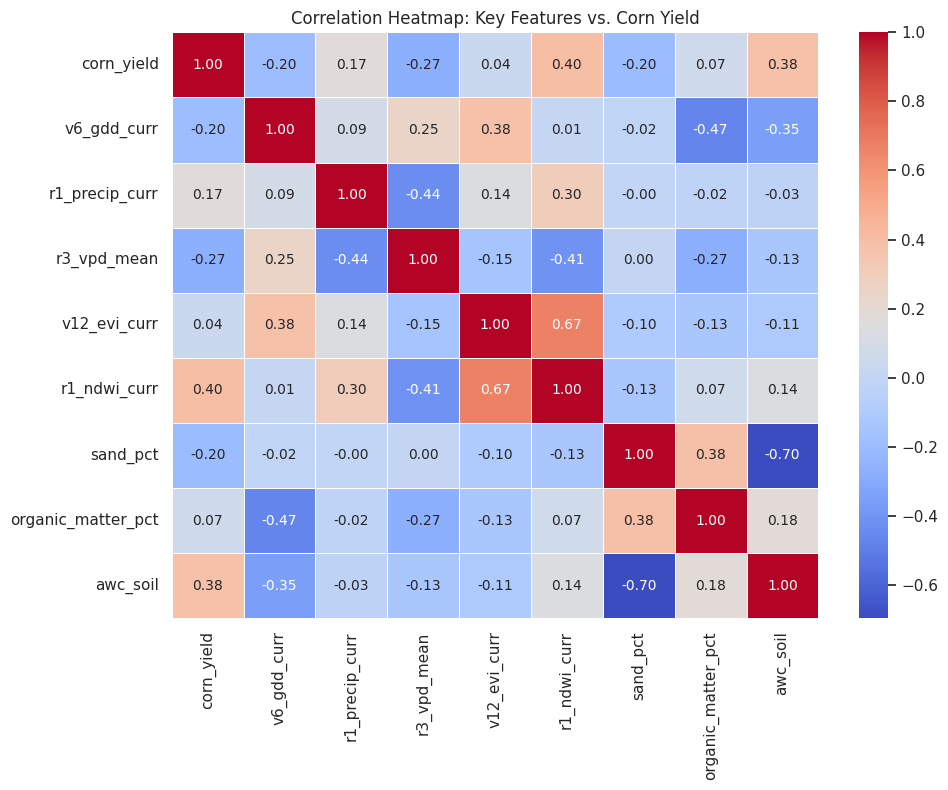

In [26]:
# We pick a subset of key features to avoid a "hairball" of 100+ columns
key_features = [
    'corn_yield', 'v6_gdd_curr', 'r1_precip_curr', 'r3_vpd_mean', 
    'v12_evi_curr', 'r1_ndwi_curr', 'sand_pct', 'organic_matter_pct', 'awc_soil'
]

plt.figure(figsize=(10, 8))
corr_matrix = master_df_clean[key_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Key Features vs. Corn Yield")
plt.tight_layout()
# plt.savefig('correlation_heatmap.png')

### Mean Corn Yield Per Year

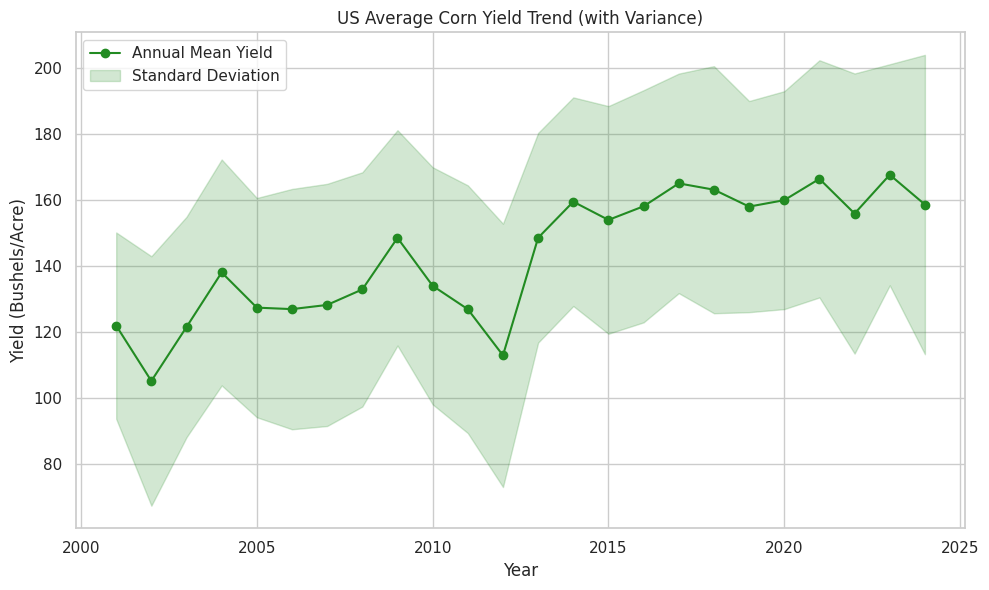

In [27]:
yield_stats = master_df_clean.groupby('year')['corn_yield'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yield_stats['year'], yield_stats['mean'], marker='o', label='Annual Mean Yield', color='forestgreen')
plt.fill_between(
    yield_stats['year'], 
    yield_stats['mean'] - yield_stats['std'], 
    yield_stats['mean'] + yield_stats['std'], 
    alpha=0.2, color='forestgreen', label='Standard Deviation'
)
plt.title("US Average Corn Yield Trend (with Variance)")
plt.xlabel("Year")
plt.ylabel("Yield (Bushels/Acre)")
plt.legend()
plt.tight_layout()
# plt.savefig('yield_trend.png')

### Feature vs. Yield Scatter Plots

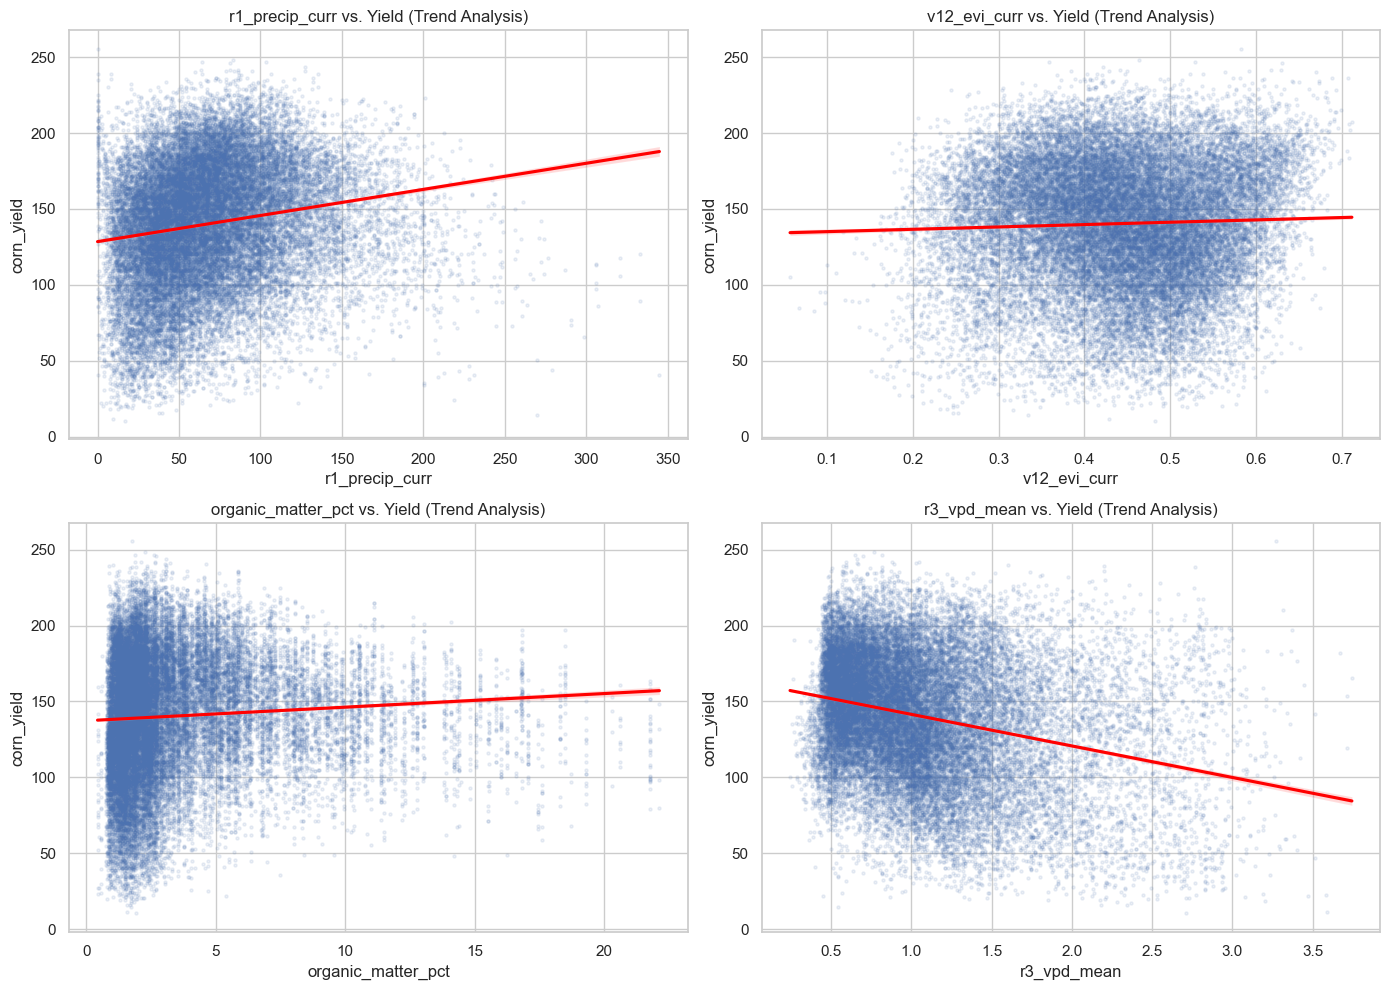

In [65]:
features_to_plot = ['r1_precip_curr', 'v12_evi_curr', 'organic_matter_pct', 'r3_vpd_mean']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    # sns.regplot helps visualize the underlying trend within the "blob"
    sns.regplot(
        data=master_df_clean, x=col, y='corn_yield', 
        ax=axes[i], 
        scatter_kws={'alpha':0.1, 's':5}, 
        line_kws={'color':'red'}
    )
    axes[i].set_title(f"{col} vs. Yield (Trend Analysis)")

plt.tight_layout()

# plt.savefig('feature_scatter_grid.png')

### Geospatial Yield Map

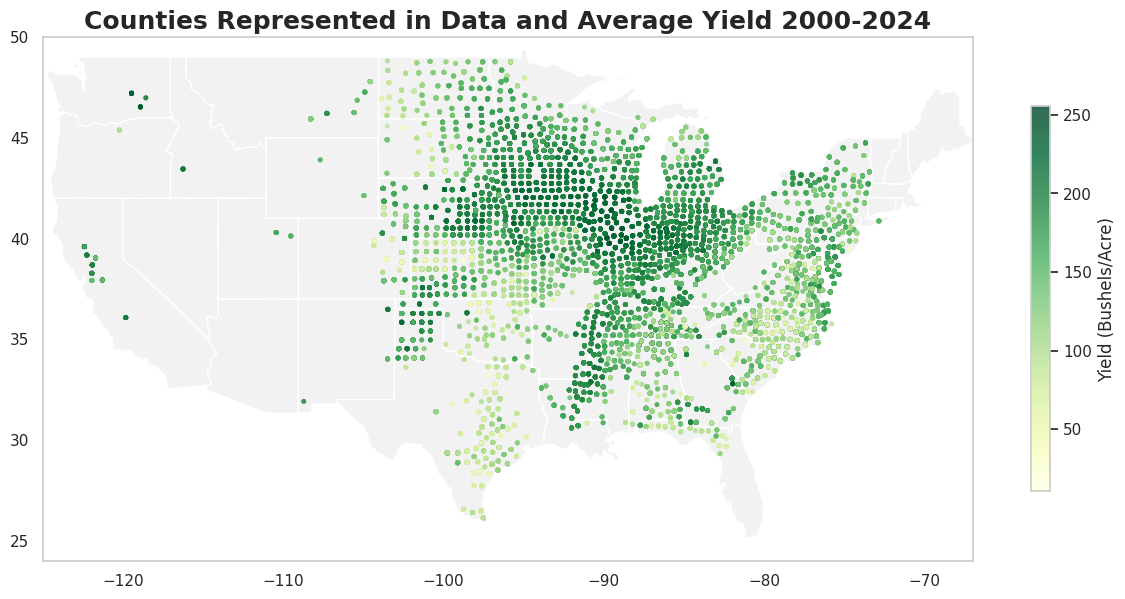

In [30]:
# URL for a GeoJSON file of US States (more detailed than the old 'lowres' world map)
usa_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"

# 1. Load the map
usa_states = gpd.read_file(usa_url)

# 2. Prepare the plot
fig, ax = plt.subplots(figsize=(15, 10))

# 3. Plot the background (States outline)
# We exclude Alaska, Hawaii, and Puerto Rico for a cleaner "Lower 48" view
lower_48 = usa_states[~usa_states['name'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]
lower_48.plot(ax=ax, color='#f2f2f2', edgecolor='white', linewidth=1)

# 4. Overlay your corn data
# Using a 'viridis' or 'YlGn' (Yellow-Green) colormap is great for agricultural yield
sc = ax.scatter(
    master_df_clean['lon'], 
    master_df_clean['lat'], 
    c=master_df_clean['corn_yield'], 
    cmap='YlGn', 
    s=12,            # Slightly larger dots for visibility
    alpha=0.8,       # Slight transparency to handle overlapping dots
    # edgecolor='black',
    linewidth=0.1
)

# 5. Aesthetics
plt.colorbar(sc, ax=ax, shrink=0.5, label='Yield (Bushels/Acre)')
plt.title("Counties Represented in Data and Average Yield 2000-2024", fontsize=18, fontweight='bold')
#plt.xlabel("Longitude")
#plt.ylabel("Latitude")

# Zoom in on the continental US
ax.set_xlim([-125, -67])
ax.set_ylim([24, 50])

# Optional: Remove the box/axes for a "clean" map look
# sns.despine(left=True, bottom=True)
plt.grid(False) 

plt.show()
# plt.savefig('geospatial_map.png')

### Corn Yield Distribution Histogram

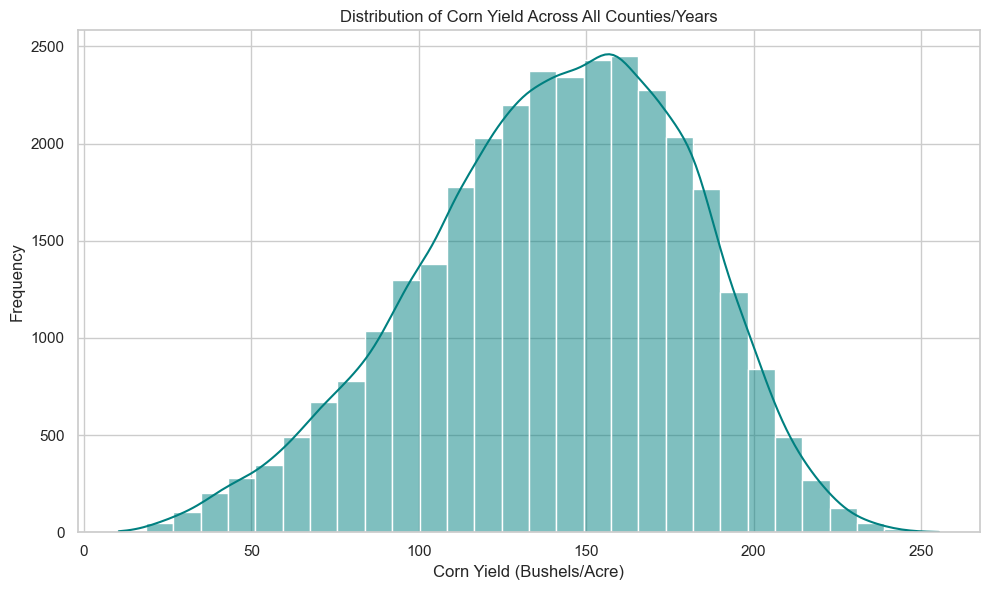

In [67]:
plt.figure(figsize=(10, 6))
sns.histplot(master_df_clean['corn_yield'], kde=True, color='teal', bins=30)
plt.title("Distribution of Corn Yield Across All Counties/Years")
plt.xlabel("Corn Yield (Bushels/Acre)")
plt.ylabel("Frequency")
plt.tight_layout()
# plt.savefig('yield_histogram.png')

### Growth Stage Sensitivity Analysis

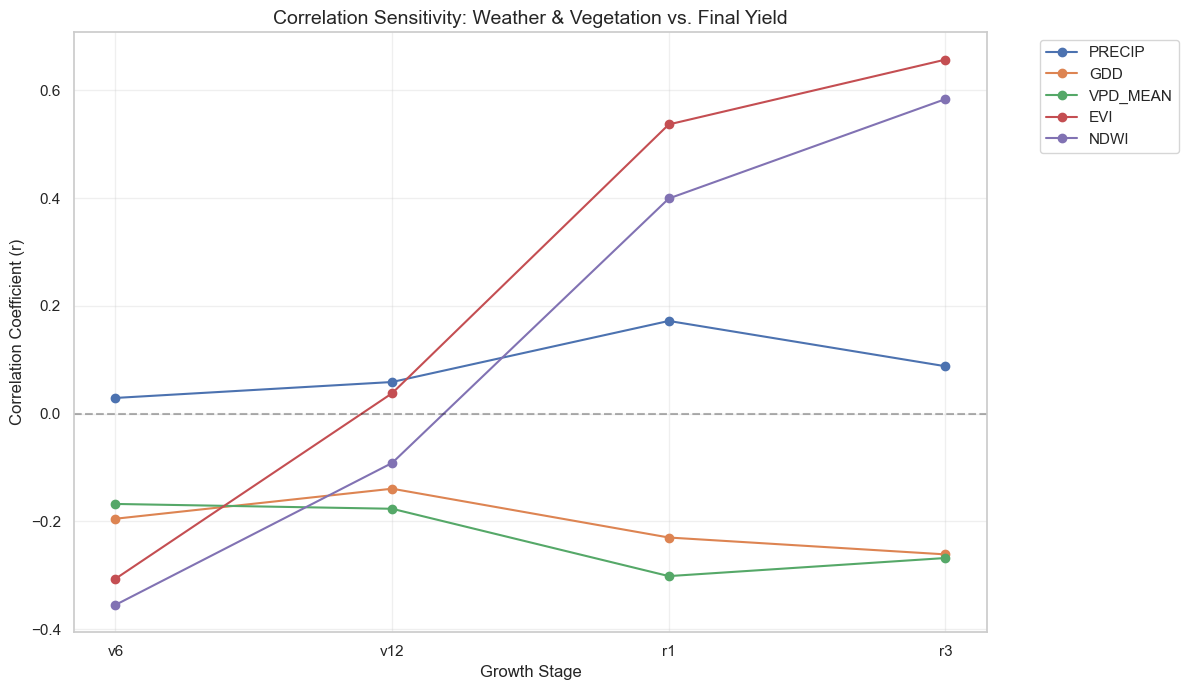

In [68]:
stages = ['v6', 'v12', 'r1', 'r3']
# Define the base metrics we want to track
metrics = ['precip_curr', 'gdd_curr', 'vpd_mean', 'evi_curr', 'ndwi_curr']

# Dictionary to store correlations
sensitivity_data = {metric: [] for metric in metrics}

for stage in stages:
    for metric in metrics:
        col_name = f"{stage}_{metric}"
        correlation = master_df_clean['corn_yield'].corr(master_df_clean[col_name])
        sensitivity_data[metric].append(correlation)

# Plotting
plt.figure(figsize=(12, 7))
for metric, values in sensitivity_data.items():
    plt.plot(stages, values, marker='o', label=metric.replace('_curr', '').upper())

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Correlation Sensitivity: Weather & Vegetation vs. Final Yield", fontsize=14)
plt.xlabel("Growth Stage", fontsize=12)
plt.ylabel("Correlation Coefficient (r)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('stage_sensitivity.png')

### Error by Year Boxplot

C:\Users\praka\AppData\Local\Temp\ipykernel_26152\350696902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df_clean, x='year', y='corn_yield', palette="Spectral")


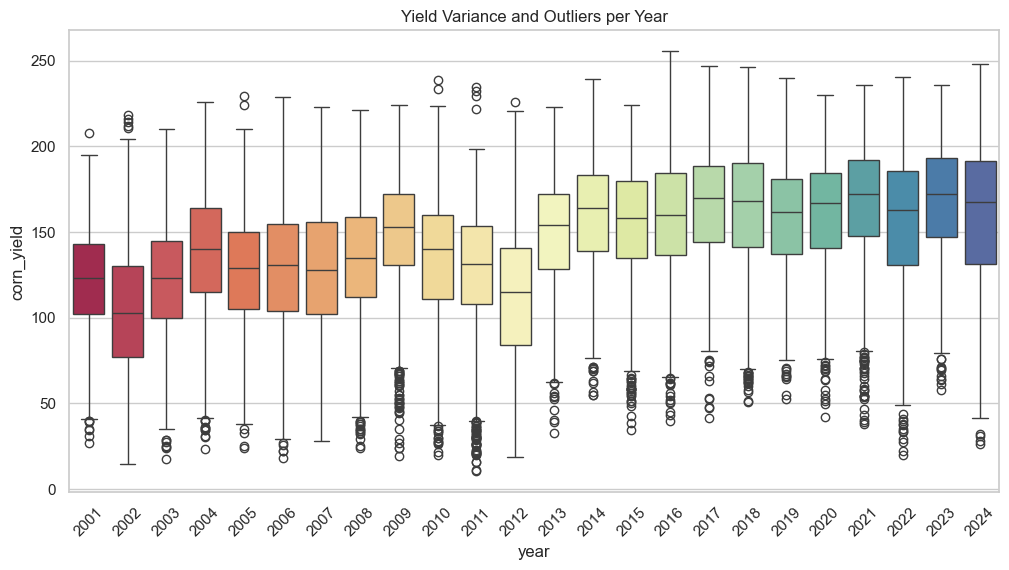

In [69]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=master_df_clean, x='year', y='corn_yield', palette="Spectral")
plt.xticks(rotation=45)
plt.title("Yield Variance and Outliers per Year")
plt.show()

## Save Data

In [72]:
master_df_clean.to_csv(r'Processed Data\fullData.csv', index=False)

## Cleaning for machine learning training

In [4]:
full_df = pd.read_csv(r'Processed Data/fullData.csv')

In [7]:
# Count unique counties
# Assumes your column name is 'County' (adjust if it is 'county_name' or 'GEOID')
unique_counties = full_df['county'].nunique()

print(f"Total unique counties represented: {unique_counties}")

# Optional: See a breakdown by year to ensure consistency across your v6-r3 stages
county_year_check = full_df.groupby('year')['county'].nunique()
print("\nUnique counties per year:")
print(county_year_check)

Total unique counties represented: 1107

Unique counties per year:
year
2001    1001
2002    1020
2003    1049
2004    1028
2005    1024
2006    1007
2007     995
2008     875
2009     794
2010     844
2011     876
2012     869
2013     814
2014     774
2015     750
2016     747
2017     751
2018     708
2019     633
2020     689
2021     769
2022     744
2023     746
2024     675
Name: county, dtype: int64


In [6]:
pd.set_option('display.max_rows', None)
full_df.dtypes



year                             int64
state                              str
state_ansi                       int64
county                             str
county_ansi                      int64
fips                             int64
lon                            float64
lat                            float64
yield_prev_year                float64
yield_prev_five                float64
acres_planted_curr             float64
acres_planted_raw_anom         float64
acres_planted_pct_anom         float64
abandonment_rate_prev_five     float64
corn_yield                     float64
corn_yield_anom                float64
acres_harvested_curr           float64
gdd_full_season_hist           float64
precip_full_season_hist        float64
precip_oct_april_curr          float64
precip_oct_april_anom          float64
extreme_cold_nov_mar           float64
v6_precip_curr                 float64
v6_precip_anom                 float64
v6_gdd_curr                    float64
v6_gdd_anom              

### Drop redundant/unneeded columns

In [7]:
# Transform year to years after 2000 as discussed
full_df['year_index'] = full_df['year'] - 2000

In [8]:
# define columns to drop. we are still keeping fips and year right now for indexing, but they will be dropped too eventually
drop_cols = ['county', 'county_ansi', 'state', 'state_ansi', 'acres_harvested_curr']
full_df.drop(columns=drop_cols, axis=1, inplace=True)

In [9]:
# Check for redundancy with correlation analysis
def check_redundancy(df, threshold=0.90):
    # Calculate absolute correlation matrix
    corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
    
    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    print(f"Features suggested for dropping (Correlation > {threshold}):")
    for col in to_drop:
        # Find which column it is correlated with
        correlated_with = upper.index[upper[col] > threshold].tolist()
        print(f" - {col} is highly correlated with: {correlated_with}")
    
    return to_drop

# Run the check (we won't drop yet, but this identifies them)
redundant_features = check_redundancy(full_df)

Features suggested for dropping (Correlation > 0.9):
 - gdd_full_season_hist is highly correlated with: ['lat']
 - v6_days_above_95_curr is highly correlated with: ['v6_sdd_curr']
 - v6_night_temp_curr is highly correlated with: ['v6_gdd_curr']
 - v6_night_temp_anom is highly correlated with: ['v6_gdd_anom']
 - v12_precip_anom is highly correlated with: ['v12_precip_curr']
 - v12_days_above_95_curr is highly correlated with: ['v12_sdd_curr']
 - v12_night_temp_curr is highly correlated with: ['v12_gdd_curr']
 - v12_night_temp_anom is highly correlated with: ['v12_gdd_anom']
 - r1_precip_anom is highly correlated with: ['r1_precip_curr']
 - r1_days_above_95_curr is highly correlated with: ['r1_sdd_curr']
 - r1_days_above_95_anom is highly correlated with: ['r1_sdd_anom']
 - r1_vpd_anom is highly correlated with: ['r1_sdd_anom']
 - r1_night_temp_curr is highly correlated with: ['r1_gdd_curr']
 - r1_night_temp_anom is highly correlated with: ['r1_gdd_anom']
 - r3_days_above_95_curr is high

### Split into ML-ready datasets

In [10]:
# Static/Background features available at all stages
static_features = [
    'year_index', 'lat', 'lon', 'yield_prev_year', 'yield_prev_five', 
    'acres_planted_curr', 'acres_planted_raw_anom', 'acres_planted_pct_anom', 
    'abandonment_rate_prev_five', 'gdd_full_season_hist', 'precip_full_season_hist',
    'precip_oct_april_curr', 'precip_oct_april_anom', 'extreme_cold_nov_mar',
    'slope', 'sand_pct', 'silt_pct', 'clay_pct', 'organic_matter_pct', 
    'pH_soil', 'awc_soil', 'cec_soil'
]

# Temporal stage features
v6_cols = [col for col in full_df.columns if 'v6_' in col]
v12_cols = [col for col in full_df.columns if 'v12_' in col]
r1_cols = [col for col in full_df.columns if 'r1_' in col]
r3_cols = [col for col in full_df.columns if 'r3_' in col]

# Outputs
targets = ['corn_yield', 'corn_yield_anom']

def finalize_dataset(df, feature_cols, target_cols, stage_name):
    # Phase 2: Temporal Split based on your latest logic
    train_raw = df[df['year'] <= 2020].copy()
    val_raw   = df[(df['year'] >= 2021) & (df['year'] <= 2022)].copy()
    test_raw  = df[df['year'] >= 2023].copy()
    
    # Phase 4: Standardization (Inputs X)
    scaler_x = StandardScaler()
    X_train_scaled = scaler_x.fit_transform(train_raw[feature_cols])
    X_val_scaled   = scaler_x.transform(val_raw[feature_cols])
    X_test_scaled  = scaler_x.transform(test_raw[feature_cols])
    
    # Phase 4: Standardization (Outputs y)
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(train_raw[target_cols])
    y_val_scaled   = scaler_y.transform(val_raw[target_cols])
    y_test_scaled  = scaler_y.transform(test_raw[target_cols])
    
    # Phase 5: Randomization (Shuffle Training Set ONLY)
    # This prevents the model from learning geographic order (e.g., all Alabama first)
    X_train_final, y_train_final = shuffle(X_train_scaled, y_train_scaled, random_state=42)
    
    # Pack into a clean dictionary
    return {
        'X_train': X_train_final, 'y_train': y_train_final,
        'X_val': X_val_scaled,     'y_val': y_val_scaled,
        'X_test': X_test_scaled,   'y_test': y_test_scaled,
        'feature_names': feature_cols,
        'scaler_x': scaler_x,      'scaler_y': scaler_y,
        'y_test_raw': test_raw[target_cols].values # For final real-world error check
    }

In [11]:
stage_datasets = {}

# Cumulative growth stage logic
stage_features = {
    'V6':  static_features + v6_cols,
    'V12': static_features + v6_cols + v12_cols,
    'R1':  static_features + v6_cols + v12_cols + r1_cols,
    'R3':  static_features + v6_cols + v12_cols + r1_cols + r3_cols
}

for stage, cols in stage_features.items():
    stage_datasets[stage] = finalize_dataset(full_df, cols, targets, stage)
    print(f"✅ Prepared {stage}: {len(cols)} features | Train rows: {stage_datasets[stage]['X_train'].shape[0]}")

# Example: How to access the data later
# X = stage_datasets['V12']['X_train']

✅ Prepared V6: 42 features | Train rows: 27003
✅ Prepared V12: 62 features | Train rows: 27003
✅ Prepared R1: 82 features | Train rows: 27003
✅ Prepared R3: 102 features | Train rows: 27003


In [12]:
joblib.dump(stage_datasets, r'Processed Data\mlData.joblib')

['Processed Data\\mlData.joblib']